# 03 — Clustering per Zona

Fase 1 riset: "Mengelompokkan POI berdasarkan lokasi geografis ... untuk
memudahkan penjadwalan per hari (cluster per zona wilayah Jakarta)".
K-Means by lat/lon -> `zone_id`. Hasil jadi basis scope `time_matrix`
(04_time_matrix.ipynb) -- matrix in-zone dihitung antar-venue dalam zone
sama; all-pairs untuk lookup GA/PSO cross-zone.

In [1]:
import os, sys
# ROOT idempoten: jangan naik lagi kalau sudah di root (aman run berulang)
if not os.path.exists("config.py"):
    os.chdir(os.path.abspath(".."))
sys.path.insert(0, os.getcwd())

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import config

print("Root:", os.getcwd())

Root: D:\humic\sistem rekomendasi destinasi wisata jakarta


## [RUN] Jalankan clustering (K-Means k=8)

Input: `merged_venues_enriched.csv` (219 venue) → Output:
`jakarta_tourism_venues_clustered.csv` (+zone_id) & `jakarta_tourism_venues.csv`
(tanpa zone_id). Cache-aware: skip kalau output sudah ada (hapus file untuk rebuild).

In [2]:
# [RUN] Clustering K-Means per zona (inline dari cluster_zones.py)
def run_clustering():
    df = pd.read_csv(config.MERGED_VENUES_ENRICHED_CSV)
    print(f"Venue input (merged): {len(df)}")

    coords = df[["latitude", "longitude"]].to_numpy()
    km = KMeans(n_clusters=config.CLUSTER_K, random_state=config.RANDOM_SEED, n_init=10)
    df["zone_id"] = km.fit_predict(coords)

    print(f"\nDistribusi venue per zone (k={config.CLUSTER_K}):")
    print(df["zone_id"].value_counts().sort_index().to_string())

    os.makedirs(os.path.dirname(config.CLUSTERED_VENUES_CSV), exist_ok=True)
    df.to_csv(config.CLUSTERED_VENUES_CSV, index=False)
    print(f"\nTersimpan -> {config.CLUSTERED_VENUES_CSV}")

    # Output pre-clustering (tanpa zone_id) untuk rekan/eksternal
    df.drop(columns=["zone_id"]).to_csv(config.TOURISM_VENUES_CSV, index=False)
    print(f"Tersimpan -> {config.TOURISM_VENUES_CSV}")
    return df


if os.path.exists(config.CLUSTERED_VENUES_CSV):
    print(f"[skip] {config.CLUSTERED_VENUES_CSV} sudah ada.")
    print("       Hapus file untuk rebuild clustering.")
else:
    run_clustering()

Venue input (merged): 162



Distribusi venue per zone (k=8):
zone_id
0    37
1    18
2    13
3     5
4    47
5    12
6    10
7    20

Tersimpan -> data/processed/jakarta_tourism_venues_clustered.csv
Tersimpan -> data/processed/jakarta_tourism_venues.csv


In [3]:
df = pd.read_csv(config.CLUSTERED_VENUES_CSV)
print(f"Total venue: {len(df)}")
print(f"Jumlah zona (k={config.CLUSTER_K}):")
df["zone_id"].value_counts().sort_index()

Total venue: 162
Jumlah zona (k=8):


zone_id
0    37
1    18
2    13
3     5
4    47
5    12
6    10
7    20
Name: count, dtype: int64

In [4]:
# Cuplikan dataset final — kolom kunci untuk slide presentasi
cols_show = ['venue_id', 'name', 'venue_category', 'latitude', 'longitude',
             'google_rating', 'time_spent_minutes', 'zone_id']
df[cols_show].head(8)

,venue_id,name,venue_category,latitude,longitude,google_rating,time_spent_minutes,zone_id
0,6,Monumen Nasional (MONAS),Monument / Landmark,-6.175372,106.827192,4.6,42,4
1,27507,Batavia (Kota Tua),Historic Site,-6.134800,106.813041,4.6,77,0
2,458,Dunia Fantasi (DUFAN),Theme Park,-6.124300,106.832089,4.6,254,0
3,13521,Patung Dirgantara (Patung Pancoran),Monument / Landmark,-6.243148,106.843705,4.5,30,5
4,457,SeaWorld Indonesia,Aquarium,-6.125733,106.842714,4.5,108,0
5,8318,Ekayana Arama Indonesia Buddhist Centre,Temple,-6.177897,106.778192,4.7,43,7
6,328,Museum Nasional Indonesia,Museum,-6.176206,106.822854,4.7,106,4
7,1629,Patung Pahlawan (Tugu Tani),Monument / Landmark,-6.182604,106.834693,4.5,31,4


## Sebaran geografis per zona

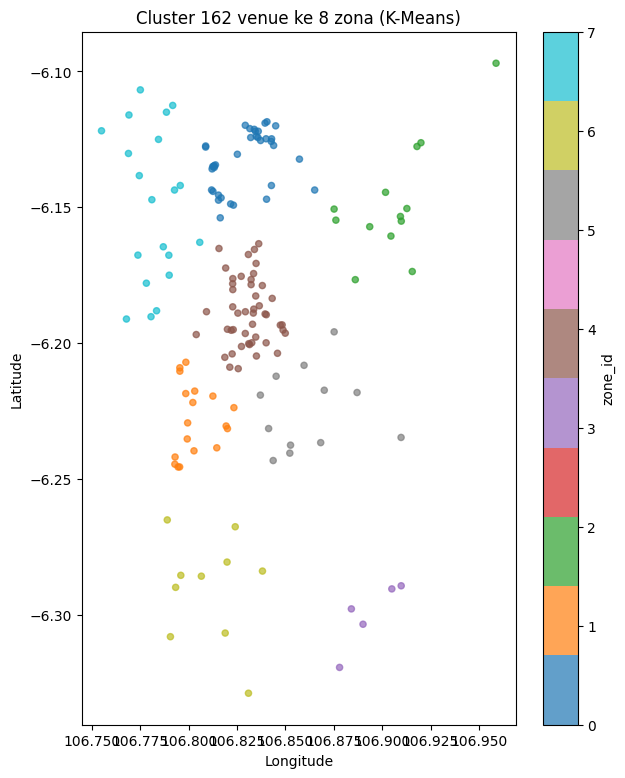

In [5]:
fig, ax = plt.subplots(figsize=(7, 9))
scatter = ax.scatter(df["longitude"], df["latitude"], c=df["zone_id"],
                      cmap="tab10", s=20, alpha=0.7)
ax.set_title(f"Cluster {len(df)} venue ke {config.CLUSTER_K} zona (K-Means)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(scatter, label="zone_id", ticks=range(config.CLUSTER_K))
plt.show()

## Kategori dominan per zona

Sanity check: tiap zona harus punya karakter geografis yang masuk akal
(cth zona pesisir didominasi Beach/Theme Park, zona pusat kota didominasi
Museum/Monument).

In [6]:
for zone in sorted(df["zone_id"].unique()):
    top_cat = df[df["zone_id"] == zone]["venue_category"].value_counts().head(3)
    n = len(df[df["zone_id"] == zone])
    print(f"zone {zone} ({n} venue): {dict(top_cat)}")

zone 0 (37 venue): {'Beach': np.int64(8), 'Temple': np.int64(5), 'Church': np.int64(4)}
zone 1 (18 venue): {'Museum': np.int64(5), 'History Museum': np.int64(2), 'Monument / Landmark': np.int64(2)}
zone 2 (13 venue): {'Church': np.int64(5), 'Museum': np.int64(3), 'Monument / Landmark': np.int64(1)}
zone 3 (5 venue): {'Monument / Landmark': np.int64(1), 'Theme Park': np.int64(1), 'Museum': np.int64(1)}
zone 4 (47 venue): {'History Museum': np.int64(11), 'Museum': np.int64(6), 'Art Museum': np.int64(5)}
zone 5 (12 venue): {'Church': np.int64(4), 'Temple': np.int64(3), 'Park': np.int64(2)}
zone 6 (10 venue): {'Museum': np.int64(3), 'Art Museum': np.int64(2), 'History Museum': np.int64(1)}
zone 7 (20 venue): {'Temple': np.int64(10), 'Church': np.int64(3), 'Historic Site': np.int64(2)}


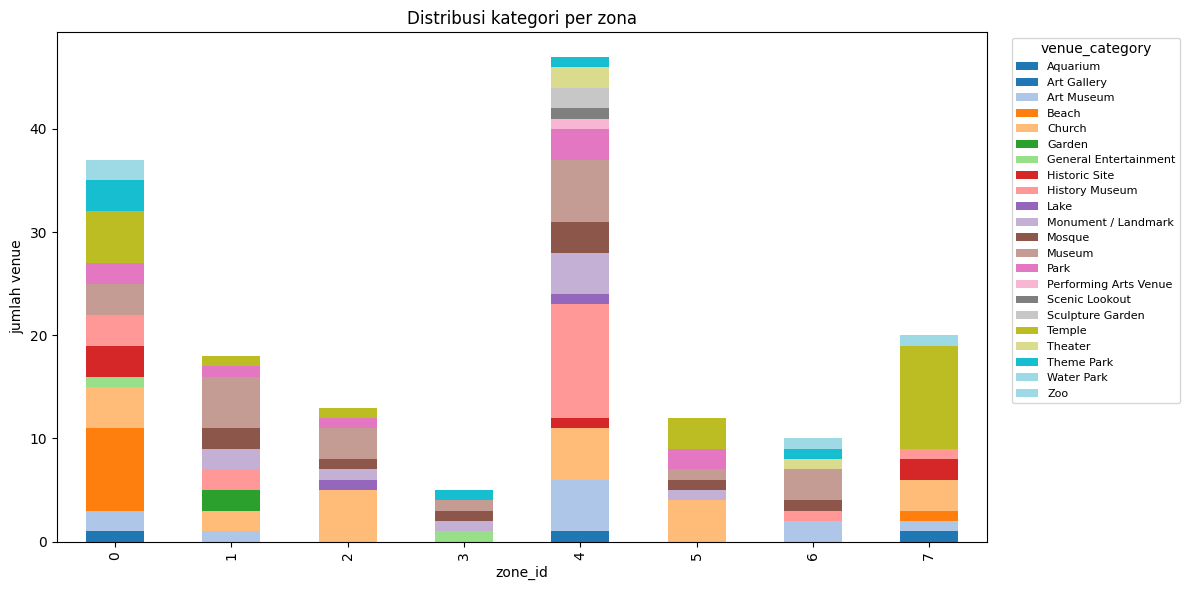

In [7]:
pivot = pd.crosstab(df["zone_id"], df["venue_category"])
ax = pivot.plot(kind="bar", stacked=True, figsize=(12, 6), legend=True,
                colormap="tab20")
ax.legend(title="venue_category", bbox_to_anchor=(1.02, 1), loc="upper left",
          fontsize=8)
plt.title("Distribusi kategori per zona")
plt.xlabel("zone_id")
plt.ylabel("jumlah venue")
plt.tight_layout()
plt.show()

## Silhouette Score — justifikasi pemilihan k

Evaluasi kualitas clustering (untuk laporan): silhouette mengukur seberapa
cocok venue dengan zonanya sendiri vs zona tetangga (−1..1, makin tinggi
makin baik). Dibandingkan k=4..12.

**Catatan penting**: skor tertinggi ada di k=10 (0.5851), bukan k=8 (0.5673)
yang dipakai. k=8 tetap dipilih dengan pertimbangan praktis, bukan murni
mengejar skor tertinggi:
- Selisih k=8 -> k=10 kecil (+0.018), diminishing return, tidak sebanding
  dengan tambahan kompleksitas 2 zona ekstra untuk GA/PSO.
- k=10 memecah beberapa zona jadi sangat kecil (8–11 venue) yang tidak
  menambah makna geografis — cenderung noise clustering, bukan kawasan
  wisata baru yang jelas.
- k=8 memberi distribusi venue per zona lebih seimbang (11–50 venue) dan
  lebih match dengan kawasan wisata nyata di Jakarta (mis. TMII, Kota Tua,
  Ancol) — pertimbangan domain knowledge, bukan cuma metrik statistik.

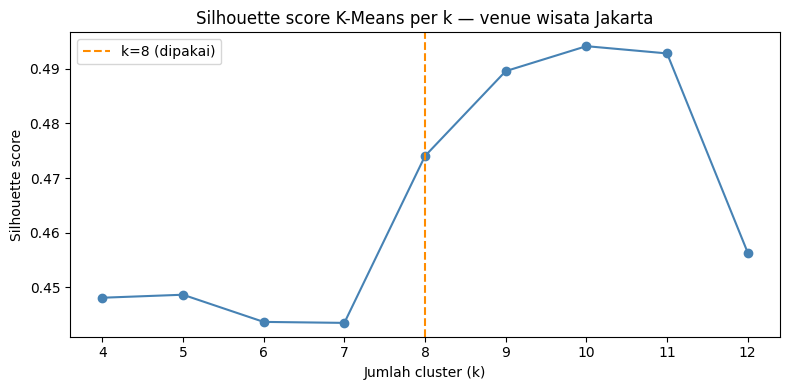

k= 4: 0.4481
k= 5: 0.4486
k= 6: 0.4437
k= 7: 0.4435
k= 8: 0.4740  <- dipakai
k= 9: 0.4896
k=10: 0.4941
k=11: 0.4928
k=12: 0.4563


In [8]:
# [STATS] Silhouette score utk k=4..12
from sklearn.metrics import silhouette_score

coords = df[["latitude", "longitude"]].to_numpy()
ks = range(4, 13)
scores = []
for k in ks:
    km_k = KMeans(n_clusters=k, random_state=config.RANDOM_SEED, n_init=10)
    labels = km_k.fit_predict(coords)
    scores.append(silhouette_score(coords, labels))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(ks), scores, marker="o", color="steelblue")
ax.axvline(config.CLUSTER_K, color="darkorange", linestyle="--",
           label=f"k={config.CLUSTER_K} (dipakai)")
ax.set_xlabel("Jumlah cluster (k)")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette score K-Means per k — venue wisata Jakarta")
ax.legend()
plt.tight_layout()
plt.show()

for k, s in zip(ks, scores):
    mark = "  <- dipakai" if k == config.CLUSTER_K else ""
    print(f"k={k:2d}: {s:.4f}{mark}")